<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/AI_2026_pytorch_soda_can.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# Optimization of Surface-to-Volume Ratio in a Cylinder

## Problem Statement

Given a cylindrical can of fixed volume $(V_0)$, we want to determine the radius $(r)$ that minimizes the surface-to-volume ratio. The surface area is related to material cost, so minimizing this ratio is important for cost efficiency.

## Define the Surface Area and Volume

- **Volume**:  
  $$ V = \pi r^2 h $$
- **Surface Area** (sum of lateral and two circular areas):  
  $$ S = 2\pi r h + 2\pi r^2 $$

We aim to minimize the ratio $(S/V)$:

$$ \frac{S}{V} = \frac{2\pi r h + 2\pi r^2}{\pi r^2 h} $$



$$= \frac{2(h+r)}{rh}$$

## T fixed volume $(V=33\ cl)$


$$
\frac{S}{V} = \frac{2}{r} + \frac{2\pi r^2}{V_0}
$$



##Find the Critical Points

To minimize $(S/V)$, we take the derivative with respect to $(r)$:

$$
\frac{d}{dr} \left( \frac{2}{r} + \frac{2\pi r^2}{V_0} \right) = -\frac{2}{r^2} + \frac{4\pi r}{V_0}
$$

Setting the derivative to zero:

$$
-\frac{2}{r^2} + \frac{4\pi r}{V_0} = 0
$$



$$
r = \left(\frac{V_0}{2\pi}\right)^{\frac{1}{3}}
$$




In [ ]:
# soda can problem
V0 = 330
SoverV0 = lambda r: (2/r + (2*np.pi * r **2) / V0)
R_opt = (V0/(2*np.pi))**(1/3)

In [ ]:
r = np.linspace(0.2,20,300)
y = SoverV0(r)

Text(0, 0.5, 'Surface Volume ratio (cm^-1)')

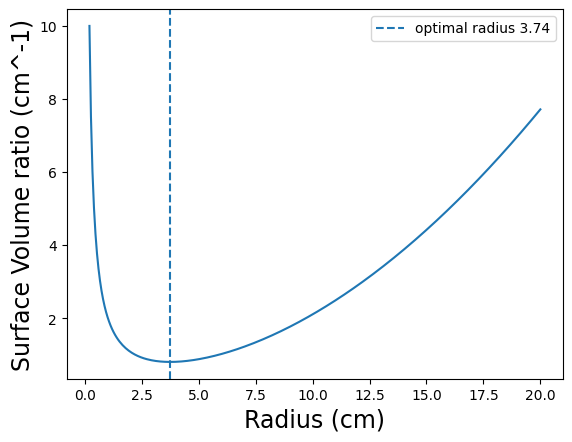

In [ ]:
plt.plot(r,y)
plt.axvline(R_opt,linestyle="--",label=f"optimal radius {np.round(R_opt,2)}")
plt.legend()
plt.xlabel("Radius (cm)" , fontsize =17)
plt.ylabel("Surface Volume ratio (cm^-1)", fontsize =17)

# Summary: How Gradient Descent Works

Gradient Descent is an optimization algorithm used to minimize a function by iteratively adjusting its parameters in the direction of the steepest descent, as defined by the negative gradient.

## Key Steps:
1. **Initialize Parameters**: Start with random values for the parameters \( \theta \).
2. **Compute the Gradient**: Calculate the derivative (gradient) of the function with respect to the parameters.
3. **Update the Parameters**: Move in the direction of the negative gradient using the update rule:

   $$
   \theta \leftarrow \theta - \eta \nabla f(\theta)
   $$

   where  $\eta$ (learning rate) controls the step size.
4. **Repeat**: Continue updating until convergence (when the gradient is close to zero or changes are minimal).

## What's about Machine Learning and Gradient Descent?

It is the same idea, but instead of minimizing any arbitrary function (like \( S/V \) in the soda can problem), we want to minimize the **expected value of the loss (or error) function** over the training data.

### Loss Function:

For a dataset with \( N \) samples, where each sample has a true target $ y_i$ and a predicted value $\tilde{y}_i(w) $, the total loss is computed as:

$$
L(w) = \frac{1}{N} \sum_{i=1}^{N} l_w(y_i, \tilde{y}_i)
$$

where:
- $ L(w)$ is the total loss function we aim to minimize.
- $ l_w(y_i, \tilde{y}_i) $ is the loss for each individual training sample, measuring the difference between the predicted and true values.
- $ w $ represents the model parameters (e.g., weights in a neural network).

### Optimization in Machine Learning:

We update the model parameters using **Gradient Descent**:

$$
w \leftarrow w - \eta \nabla L(w)
$$

## types of gradient descent (the element on which the sum is computed with)


- **Batch Gradient Descent**: Uses the entire dataset to compute the gradient.
- **Stochastic Gradient Descent (SGD)**: Updates parameters using a single random data point per iteration.
- **Mini-Batch Gradient Descent**: Uses a small batch of data to balance efficiency and stability.




In [ ]:

#write a class that solve the problem

V0 = 330  # Fixed volume
SodaCan = SoverVoptimizer(V0, learning_rate=0.2)
optimal_r = SodaCan.optimize(r_init=20)  # Start from an initial guess of r

print(f"Optimal radius: {optimal_r}")



In [ ]:
plt.plot(SodaCan.r_history,SodaCan.f_history,"+",label= "optimization steps")
plt.plot(r,y,label= "theoretical curve")
plt.axvline(R_opt,linestyle="--",label=f"optimal radius {np.round(R_opt,2)}")
plt.xlabel("Radius (cm)" , fontsize =17)
plt.ylabel("Surface Volume ratio (cm^-1)", fontsize =17)
plt.axvline(20,linestyle="--",label="init",color="k")
plt.legend()

In [ ]:
import torch.nn as nn

# Torch version
